# 99 — Final Findings

This notebook uses generated metric sidecars to consolidate the two operational lenses into a
concise technical and business-facing
conclusion, with the final design rationale and validation gate included below.

**Notebook structure:** the dashboard summarizes the recommendation, and notebooks 05 through
07 provide the supporting evidence. The analysis supports prioritization for human review.
Automatic intervention and value estimation require commercial validation.


In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

ROOT = Path('..').resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from module24_workflow import OUTPUT_CACHE, compile_evaluation

# Read generated metric sidecars; this findings notebook does not refit models.
evaluation = compile_evaluation()
activity = evaluation['workflow']['activity_forward']
pattern = evaluation['workflow']['active_pattern_forward']
print(
    f"Modeling panel: {evaluation['data_package']['customer_month_rows']:,} customer-months, "
    f"{evaluation['data_package']['customers']:,} customers."
)
display(pd.DataFrame([activity]).round(4))
display(pd.DataFrame([pattern]).round(4))
display(pd.DataFrame(evaluation['peer_strategy']['capacity_overlap']).round(4))
display(pd.DataFrame(evaluation['operational_layer']['capacity_overlap']).round(4))


Modeling panel: 564,144 customer-months, 17,128 customers.


,model,rows,activity_rate,accuracy,balanced_accuracy,f1,roc_auc,average_precision,log_loss,brier
0,hist_gradient_boosting_raw,97627,0.1538,0.8871,0.7063,0.548,0.8874,0.6523,0.2765,0.0839


,rows,classes,accuracy,macro_f1,log_loss,majority_accuracy
0,15016,"[broad, discount_heavy, multi_order, return_he...",0.6021,0.4318,1.0803,0.4863


,capacity_per_month,comparison,pooled_jaccard,changed_customer_months,mean_monthly_jaccard
0,100,channel_vs_company_division,0.6973,214,0.6985
1,100,channel_vs_hybrid,0.6973,214,0.6985
2,250,channel_vs_company_division,0.8450,252,0.8455
3,250,channel_vs_hybrid,0.8450,252,0.8455
4,500,channel_vs_company_division,0.8634,440,0.8641
5,500,channel_vs_hybrid,0.8645,436,0.8652


,capacity_per_month,channel_vs_hurdle_jaccard,channel_rows,hurdle_rows,overlap_rows
0,100,0.0850,600,600,94
1,250,0.0858,1500,1500,237
2,500,0.1272,3000,3000,677


## Executive dashboard

The dashboard brings together the four decision-relevant comparisons: activity-model performance,
peer-definition sensitivity, complementarity between the retained lenses, and the blinded-pilot
sample design.


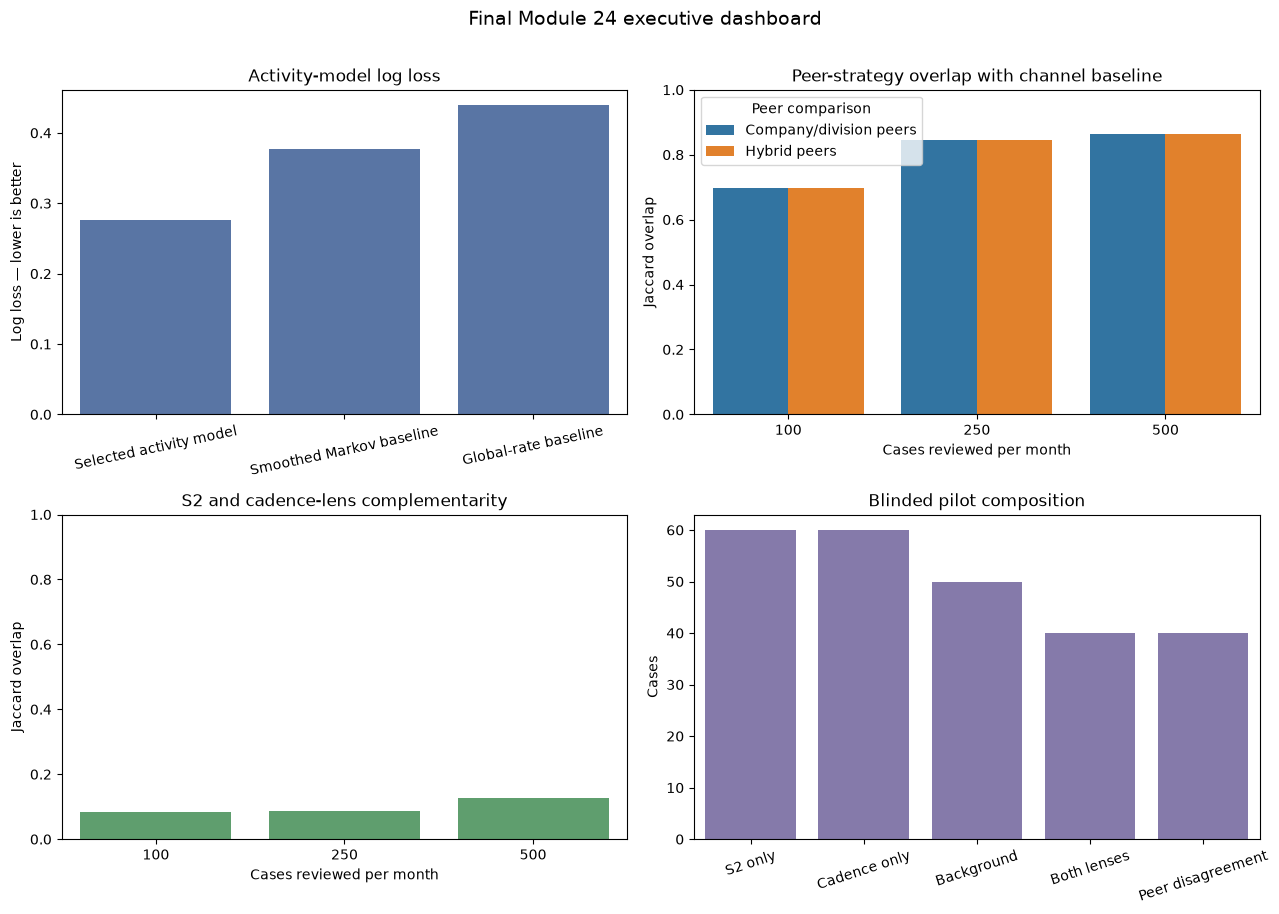

In [2]:
import json

import matplotlib.pyplot as plt
import seaborn as sns

hurdle_metrics = json.loads((OUTPUT_CACHE / '06_hurdle_metrics.json').read_text())
model_labels = {
    hurdle_metrics['operational_activity_model']: 'Selected activity model',
    'smoothed_activity_markov': 'Smoothed Markov baseline',
    'global_activity_rate': 'Global-rate baseline',
}
forward = pd.DataFrame(hurdle_metrics['forward_metrics'])
forward = forward.loc[forward['model'].isin(model_labels)].copy()
forward['Model'] = forward['model'].map(model_labels)

comparison_labels = {
    'channel_vs_company_division': 'Company/division peers',
    'channel_vs_hybrid': 'Hybrid peers',
}
peer_overlap = pd.DataFrame(evaluation['peer_strategy']['capacity_overlap']).assign(
    **{'Peer comparison': lambda frame: frame['comparison'].map(comparison_labels)}
)
lens_overlap = pd.DataFrame(evaluation['operational_layer']['capacity_overlap'])
stratum_labels = {
    'channel_only': 'S2 only',
    'hurdle_only': 'Cadence only',
    'background': 'Background',
    'agreement_core': 'Both lenses',
    'peer_definition_disagreement': 'Peer disagreement',
    'deterministic_fill': 'Capacity fill',
}
strata = (
    pd.Series(evaluation['operational_layer']['pilot_strata'], name='Cases')
    .rename_axis('sampling_stratum')
    .reset_index()
)
strata['Review stratum'] = strata['sampling_stratum'].map(stratum_labels)
strata = strata.sort_values('Cases', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.barplot(data=forward, x='Model', y='log_loss', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Activity-model log loss')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Log loss — lower is better')
axes[0, 0].tick_params(axis='x', rotation=12)

sns.barplot(
    data=peer_overlap,
    x='capacity_per_month',
    y='pooled_jaccard',
    hue='Peer comparison',
    ax=axes[0, 1],
)
axes[0, 1].set_title('Peer-strategy overlap with channel baseline')
axes[0, 1].set_xlabel('Cases reviewed per month')
axes[0, 1].set_ylabel('Jaccard overlap')
axes[0, 1].set_ylim(0, 1)

sns.barplot(
    data=lens_overlap,
    x='capacity_per_month',
    y='channel_vs_hurdle_jaccard',
    ax=axes[1, 0],
    color='#55A868',
)
axes[1, 0].set_title('S2 and cadence-lens complementarity')
axes[1, 0].set_xlabel('Cases reviewed per month')
axes[1, 0].set_ylabel('Jaccard overlap')
axes[1, 0].set_ylim(0, 1)

sns.barplot(
    data=strata,
    x='Review stratum',
    y='Cases',
    ax=axes[1, 1],
    color='#8172B2',
)
axes[1, 1].set_title('Blinded pilot composition')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Cases')
axes[1, 1].tick_params(axis='x', rotation=18)

fig.suptitle('Final Module 24 executive dashboard', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Final design rationale

The submitted design combines a business-friendly deviation lens, a temporal activity lens, and a blinded operational review gate. Each component below is supported by evidence included in this handout.


In [3]:
design_decisions = pd.DataFrame(
    [
        {
            'Component': 'Channel S2 deviation score',
            'Evidence in this handout': 'Aggregate quality checks and fixed-capacity peer queues.',
            'Operational role': 'Business-friendly investigation lens.',
        },
        {
            'Component': 'Hurdle/cadence activity model',
            'Evidence in this handout': 'Chronological validation and untouched forward metrics.',
            'Operational role': 'Temporal expectation lens.',
        },
        {
            'Component': 'Customer-clustered uncertainty',
            'Evidence in this handout': '1,000 resamples of the fixed forward period.',
            'Operational role': 'Quantifies technical sampling uncertainty.',
        },
        {
            'Component': 'Episode and pilot layer',
            'Evidence in this handout': 'Episode collapse and 250-case blinded sample.',
            'Operational role': 'Commercial validation gate.',
        },
    ]
)
display(design_decisions)


,Component,Evidence in this handout,Operational role
0,Channel S2 deviation score,Aggregate quality checks and fixed-capacity pe...,Business-friendly investigation lens.
1,Hurdle/cadence activity model,Chronological validation and untouched forward...,Temporal expectation lens.
2,Customer-clustered uncertainty,"1,000 resamples of the fixed forward period.",Quantifies technical sampling uncertainty.
3,Episode and pilot layer,Episode collapse and 250-case blinded sample.,Commercial validation gate.


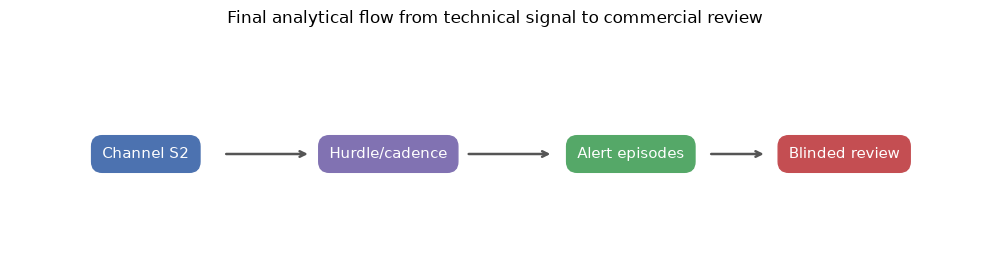

In [4]:
fig, ax = plt.subplots(figsize=(10, 2.8))
stages = [
    ('Channel S2', 0.14, '#4C72B0'),
    ('Hurdle/cadence', 0.39, '#8172B2'),
    ('Alert episodes', 0.64, '#55A868'),
    ('Blinded review', 0.86, '#C44E52'),
]
for label, x_position, color in stages:
    ax.text(
        x_position, 0.5, label, ha='center', va='center', fontsize=11, color='white',
        bbox={'boxstyle': 'round,pad=0.7', 'facecolor': color, 'edgecolor': color},
        transform=ax.transAxes,
    )
for (_, left, _), (_, right, _) in zip(stages[:-1], stages[1:], strict=True):
    ax.annotate('', xy=(right - 0.08, 0.5), xytext=(left + 0.08, 0.5),
                xycoords=ax.transAxes,
                arrowprops={'arrowstyle': '->', 'color': '#555555', 'linewidth': 1.8})
ax.set_title('Final analytical flow from technical signal to commercial review', pad=18)
ax.axis('off')
plt.tight_layout()
plt.show()


**Interpretation.** The final design produces business-friendly, capacity-aware investigation candidates. Usefulness, novelty, actionability, and operating fit are evaluated through blinded commercial review.


## Forward-comparison uncertainty

The selected activity model's improvements are accompanied by a fixed-seed, customer-clustered
bootstrap of the untouched forward period. Each replicate retains all forward months for a
sampled customer; only aggregate differences and intervals are shown.


In [5]:
uncertainty_summary = []
for comparison in hurdle_metrics['forward_uncertainty']:
    diff = comparison['selected_minus_baseline']
    uncertainty_summary.append({
        'Comparison': f"Selected minus {comparison['baseline']}",
        'Log loss difference (95% CI)': (
            f"{diff['log_loss']['point_difference']:.4f} "
            f"[{diff['log_loss']['ci_95'][0]:.4f}, {diff['log_loss']['ci_95'][1]:.4f}]"
        ),
        'ROC-AUC difference (95% CI)': (
            f"{diff['roc_auc']['point_difference']:.4f} "
            f"[{diff['roc_auc']['ci_95'][0]:.4f}, {diff['roc_auc']['ci_95'][1]:.4f}]"
        ),
    })
display(pd.DataFrame(uncertainty_summary))


,Comparison,Log loss difference (95% CI),ROC-AUC difference (95% CI)
0,Selected minus smoothed_activity_markov,"-0.1002 [-0.1028, -0.0975]","0.1943 [0.1898, 0.1982]"
1,Selected minus global_activity_rate,"-0.1628 [-0.1672, -0.1586]","0.3874 [0.3837, 0.3910]"


## Findings

- The model predicts next month's ordering activity better than simple historical comparison
  rules on the six-month test period.
- The existing S2 score remains the clearest starting point because a reviewer can trace why a
  case ranked highly.
- Changing the customer comparison group changes some of the cases sent for review, especially
  when the monthly review list is short.
- The S2 score and the activity model usually surface different customers, so the pilot should
  include cases selected by each approach.
- Commercial reviewers must decide whether those cases are useful before the workflow can claim
  business value or replace the current process.

## Recommendations

- Keep channel S2 as the business-friendly incumbent and operate hurdle/cadence as a controlled
  challenger at fixed review capacity.
- Use the blinded review as the promotion gate before process replacement or automated
  decision-making.

## Next Steps

1. Complete the blinded 250-case commercial review for usefulness, novelty, actionability,
   review effort, and operating fit.
2. Use the private allocation key to estimate results under the documented sampling design.
3. Refresh the public hash-only provenance manifest and curated submission ZIP after the final
   rerun. These steps validate handoff integrity. ROI and financial impact require separate
   commercial evidence.
